# Genomik variant analizi

## Problem
PASS/QUAL filtrindən sonra hansı variant tipləri qalır?

## Theory
VCF record bir neçə ALT daşıya bilər; allel sayı record sayından çox ola bilər.

## Data
GIAB HG001 GRCh38 v4.2.1-in ilk 1000 real qeydi.

Əvvəl `python scripts/fetch_data.py --dataset all` və paket quraşdırılması tamamlanmalıdır.

## Method
Header validation → PASS/QUAL → per-ALT type → genotype counts → Ti/Tv

## Code

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Open notebook within the bioinformatics-lab repository")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
from run_projects import RUNNERS
run_dir = RUNNERS["variants"]()
summary = json.loads((run_dir / "summary.json").read_text())
# Summarize long sequence strings in notebook output; full result is on disk.
if "records" in summary:
    displayed = {k: {"length":v["length"], "gc_fraction":v["gc_fraction_acgt_only"], "ambiguous":v["ambiguous_bases"]} for k,v in summary["records"].items()}
else:
    displayed = summary
display(displayed)


{'input_records': 1000,
 'retained_alleles': 1003,
 'excluded_records': {},
 'types': {'SNV': 867, 'indel': 136},
 'transitions': 640,
 'transversions': 227,
 'ti_tv': 2.8193832599118944,
 'min_qual': 20,
 'require_PASS': True}

## Result
Yuxarıdakı output faktiki bu notebook icrasının nəticəsidir. Aşağıda run-da yaranan qrafiklər göstərilir.

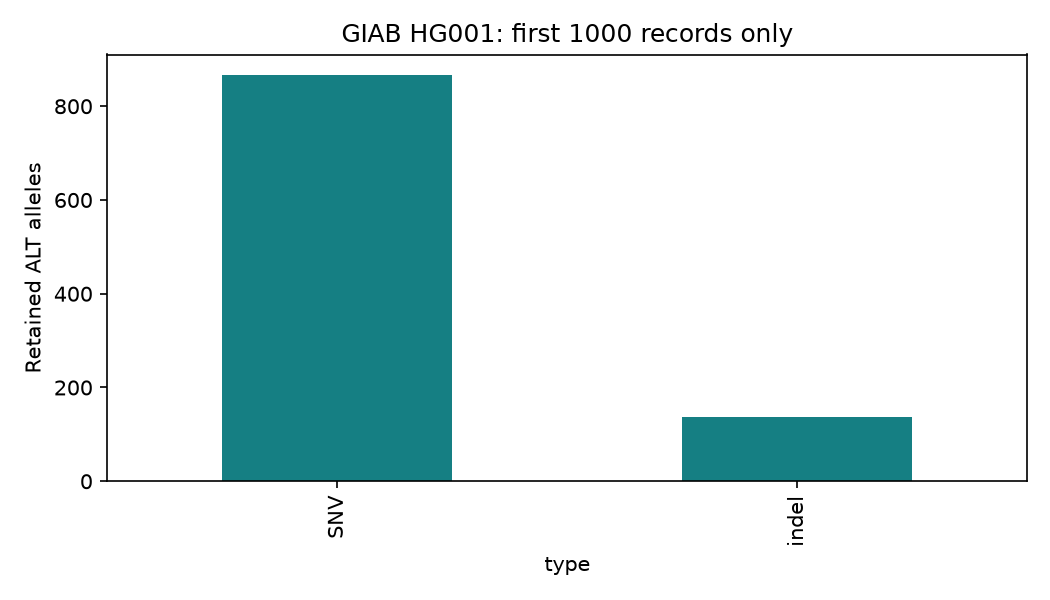

In [2]:
from IPython.display import Image, display
for figure in sorted(run_dir.glob("*.png")):
    display(Image(filename=str(figure)))

## Interpretation
Bu genomik prefix representative random sample deyil. Ti/Tv sample-specific descriptive göstəricidir.

## Conclusion
Caller precision/recall yalnız bağımsız calls və confident regions ilə ölçülə bilər.